In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})
print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1      0   19                  15                      39
1           2      0   21                  15                      81
2           3      1   20                  16                       6
3           4      1   23                  16                      77
4           5      1   31                  17                      40


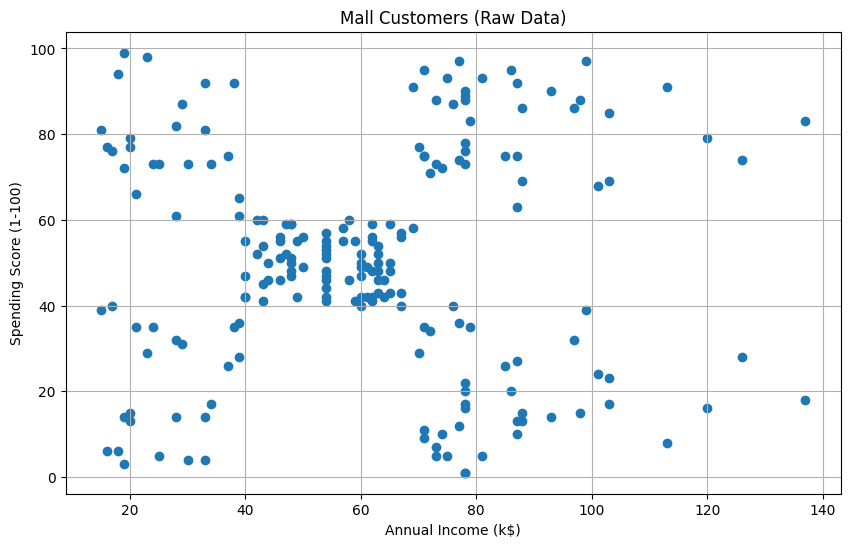

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Annual Income (k$)"],df[ "Spending Score (1-100)"])
plt.title('Mall Customers (Raw Data)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

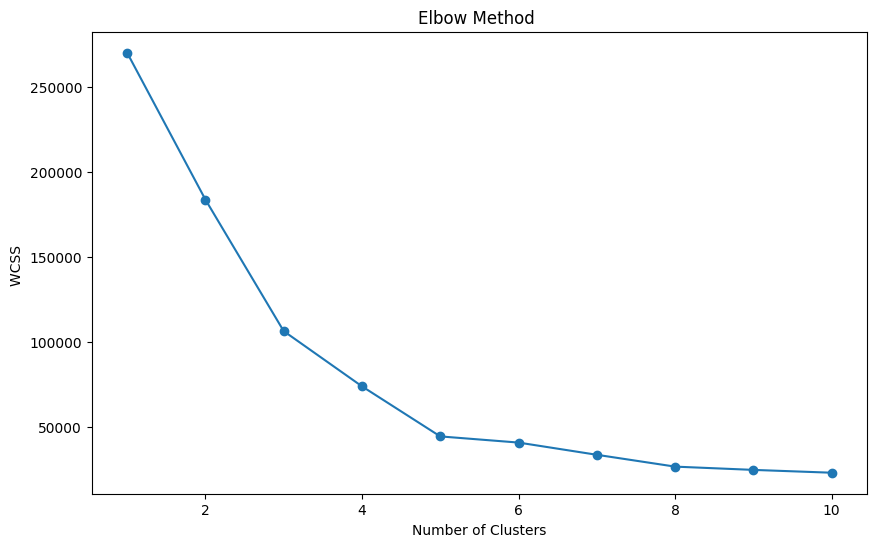

In [5]:
from sklearn.cluster import KMeans
X = df.iloc[:, [3, 4]].values
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss,marker='o' )
plt.title('Elbow Method ')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS ')
plt.show()

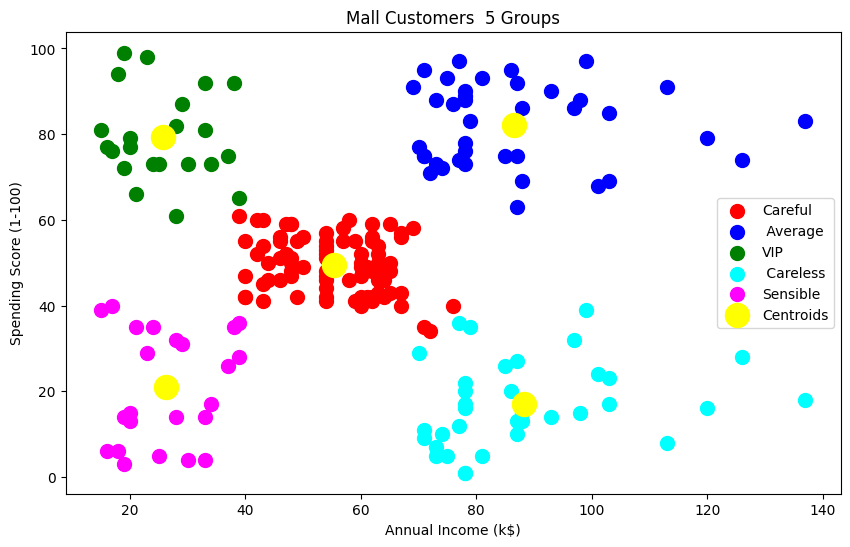

In [6]:

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Careful')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label=' Average')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='VIP')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label=' Careless')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Sensible')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Mall Customers  5 Groups')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Gender Wise Report:
        Annual Income (k$)  Spending Score (1-100)
Genre                                            
0               62.227273               48.511364
1               59.250000               51.526786


/tmp/ipython-input-2651853877.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_analysis.index, y=gender_analysis['Spending Score (1-100)'], palette="pastel")


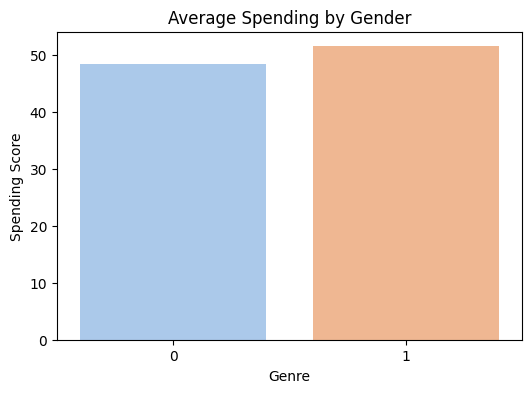

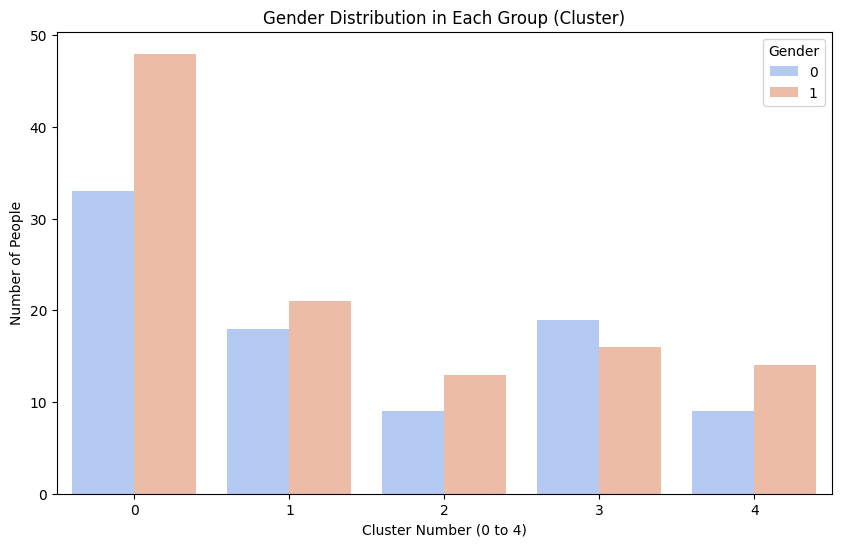

In [7]:
import seaborn as sns
gender_analysis = df.groupby('Genre')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Gender Wise Report:\n", gender_analysis)
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_analysis.index, y=gender_analysis['Spending Score (1-100)'], palette="pastel")
plt.title('Average Spending by Gender')
plt.ylabel('Spending Score')
plt.show()
df['Cluster'] = y_kmeans

plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue='Genre', data=df, palette="coolwarm")
plt.title('Gender Distribution in Each Group (Cluster)')
plt.xlabel('Cluster Number (0 to 4)')
plt.ylabel('Number of People')
plt.legend(title='Gender')
plt.show()

/tmp/ipython-input-3588246077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Age', data=df, palette='coolwarm')


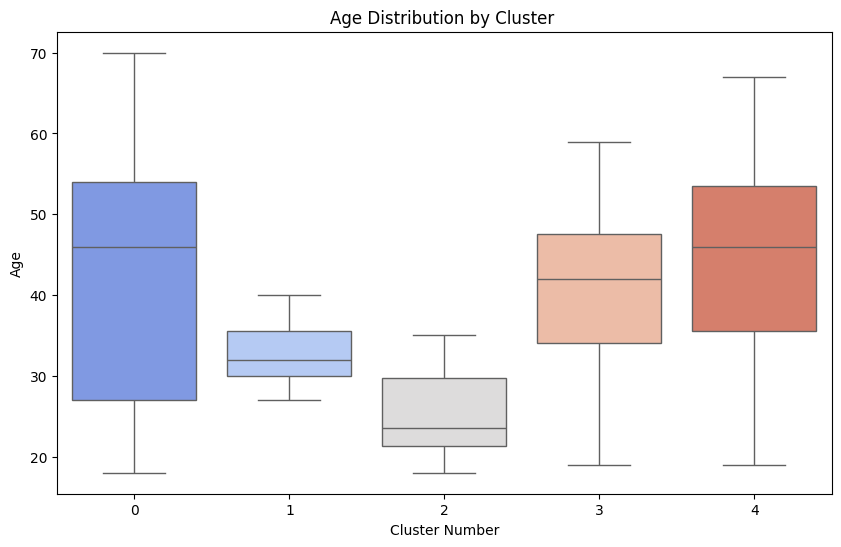

Age Group Wise Spending:
 Age_Group
Young (18-35)          60.797872
Middle-Aged (36-55)    40.712329
Senior (55+)           38.379310
Name: Spending Score (1-100), dtype: float64


/tmp/ipython-input-3588246077.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = df.groupby('Age_Group')['Spending Score (1-100)'].mean()
/tmp/ipython-input-3588246077.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_spending.index, y=age_spending.values, palette='viridis')


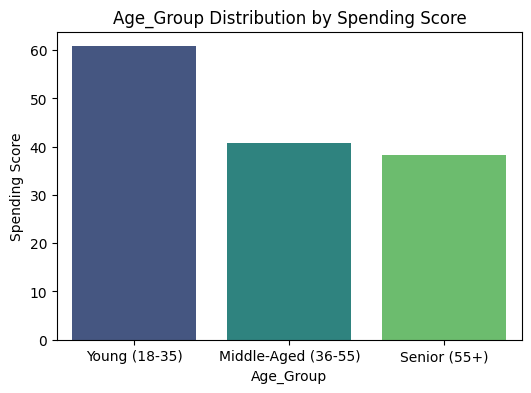

In [8]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Age', data=df, palette='coolwarm')
plt.title('Age Distribution by Cluster ')
plt.xlabel('Cluster Number')
plt.ylabel('Age')
plt.show()
bins = [18, 35, 55, 70]
labels = ['Young (18-35)', 'Middle-Aged (36-55)', 'Senior (55+)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_spending = df.groupby('Age_Group')['Spending Score (1-100)'].mean()
print("Age Group Wise Spending:\n", age_spending)

plt.figure(figsize=(6, 4))
sns.barplot(x=age_spending.index, y=age_spending.values, palette='viridis')
plt.title('Age_Group Distribution by Spending Score')
plt.xlabel('Age_Group')
plt.ylabel('Spending Score')
plt.show()